# Study 773 — Spotify-Wrapped — for the quants 🔬

The full battery: one-sample *t* per window, a random-window placebo, a leave-one-out jackknife, the costed net leg, and a seeded synthetic positive control. Everything offline once cached; fingerprint `ee0e942455bb`. Note the sample size: **n = 8** (SPOT lists April 2018).

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from spotify_wrapped import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching SPOT + SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ev = st.build_event_table(prices, cost_bps=5.0)
inc = ev[ev["included"]]
print(f"panel loaded; {len(inc)} of {len(dt.EVENTS)} Wrapped launches resolved")


panel loaded; 8 of 10 Wrapped launches resolved


## 1. One-sample *t* across independent Wrapped years

Each Wrapped launch is one independent event, so the unit is a one-sample *t* of the per-year abnormal return — **not** a daily panel (which would fake precision). With n = 8 these are small-sample statistics; read the point estimates.

In [2]:
for label, col in [('2wk run-up','pre_s'),('1mo run-up','pre_l'),('2wk fade','post_s'),('1mo fade','post_l')]:
    s = st.one_sample_t(inc[col].values)
    print(f'{label:<12s} n={s["n"]}  mean={s["mean"]*100:+.3f}%  sd={s["sd"]*100:.2f}%  t={s["t"]:+.3f}')

2wk run-up   n=8  mean=-0.676%  sd=10.78%  t=-0.177
1mo run-up   n=8  mean=-1.940%  sd=14.71%  t=-0.373
2wk fade     n=8  mean=+0.614%  sd=7.27%  t=+0.239
1mo fade     n=8  mean=+0.324%  sd=6.02%  t=+0.152


## 2. Random-window placebo — is anything outside the luck cloud?

For each event we redraw a random, non-launch 2-week window on SPOT vs SPY and recompute the abnormal return; 20 seeds × 200 draws. If the observed mean sits in the tail of that null, it isn't ordinary tracking noise. (It sits dead-centre.)

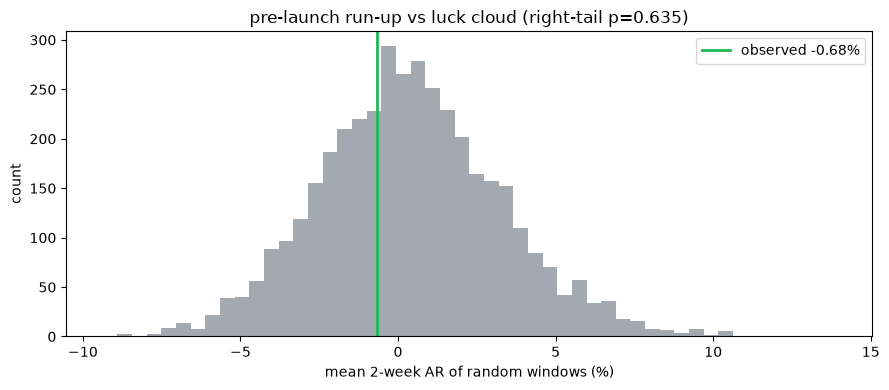

placebo: {'obs': -0.0068, 'placebo_mean': 0.004, 'placebo_sd': 0.0289, 'p_value': 0.6352, 'n_draws': 4000}


In [3]:
pl = st.placebo_pvalue(ev, prices, 'pre_s', k=10, tail='right')
import numpy as np
spot, spy = prices[dt.INSTRUMENT], prices[dt.BENCHMARK]
common = spot.index.intersection(spy.index).sort_values()
rng = np.random.default_rng(999); draws = []
for _ in range(4000):
    vals = []
    for _e in range(int(inc.shape[0])):
        p = int(rng.integers(0, len(common)-11))
        vals.append(float(spot.loc[common[p+10]]/spot.loc[common[p]] - spy.loc[common[p+10]]/spy.loc[common[p]]))
    draws.append(np.mean(vals))
fig, ax = plt.subplots(figsize=(9,4))
ax.hist(np.array(draws)*100, bins=50, color='#8b949e', alpha=0.8)
ax.axvline(pl['obs']*100, color='#1DB954', lw=2, label=f"observed {pl['obs']*100:+.2f}%")
ax.set_xlabel('mean 2-week AR of random windows (%)'); ax.set_ylabel('count')
ax.set_title(f"pre-launch run-up vs luck cloud (right-tail p={pl['p_value']:.3f})"); ax.legend()
plt.tight_layout(); plt.show()
print('placebo:', {k: round(v,4) if isinstance(v,float) else v for k,v in pl.items()})

## 3. Jackknife — is there any effect to be stable about?

In [4]:
x = inc['pre_s'].values
jk = [st.one_sample_t(np.delete(x, i))['t'] for i in range(len(x))]
print(f'full-sample t = {st.one_sample_t(x)["t"]:+.3f}')
print(f'jackknife t range [{min(jk):+.3f}, {max(jk):+.3f}] over {len(x)} leave-one-out draws')

full-sample t = -0.177
jackknife t range [-0.817, +0.424] over 8 leave-one-out draws


## 4. Tradability — net of costs

Calendar-known entry, so the signal window and the tradable window are the same (gross vs net). But there is no gross edge to erode: every cut is a sub-1% wisp on 8 events, swamped by a ~2.9% window-noise sd.

In [5]:
ev10 = st.build_event_table(prices, cost_bps=10.0); inc10 = ev10[ev10['included']]
for base, label in [('pre_s','2wk run-up'),('post_s','2wk fade')]:
    g = st.one_sample_t(inc[base].values); n5 = st.one_sample_t(inc[base+'_net'].values); n10 = st.one_sample_t(inc10[base+'_net'].values)
    print(f'{label:<12s} gross {g["mean"]*100:+.3f}% (t={g["t"]:+.2f})  net@5 {n5["mean"]*100:+.3f}% (t={n5["t"]:+.2f})  net@10 {n10["mean"]*100:+.3f}% (t={n10["t"]:+.2f})')

2wk run-up   gross -0.676% (t=-0.18)  net@5 -0.776% (t=-0.20)  net@10 -0.876% (t=-0.23)
2wk fade     gross +0.614% (t=+0.24)  net@5 +0.514% (t=+0.20)  net@10 +0.414% (t=+0.16)


## 5. Synthetic positive control — the detector works, the tape has no bump

The one-sample-*t* detector must stay quiet on a planted-null world and recover a planted pre-launch bump. Note the honest small-sample false-positive rate at n = 18 with a 10-day AR: |*t*| ≥ 2 fires on ~1/5 of null seeds — and the real study runs on n = 8, thinner still. The SPOT tape simply has no bump to find.

null: mean t=-0.43 sd=1.43  |t|>=2 in 4/20 seeds
planted +1%: mean AR +1.192%  t=+1.37
planted +2%: mean AR +2.192%  t=+2.52


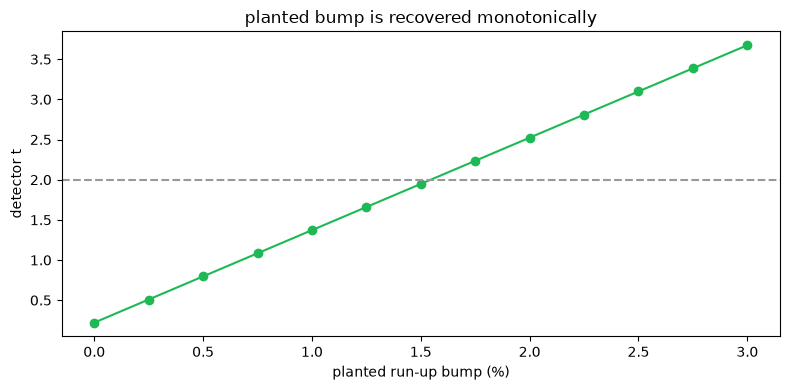

In [6]:
null_ts = np.array([st.synthetic_detect(bump=0.0, seed=777+s, k=10)['t'] for s in range(20)])
print(f'null: mean t={null_ts.mean():+.2f} sd={null_ts.std(ddof=1):.2f}  |t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds')
for b in (0.01, 0.02):
    r = st.synthetic_detect(bump=b, seed=777, k=10)
    print(f'planted +{b*100:.0f}%: mean AR {r["mean"]*100:+.3f}%  t={r["t"]:+.2f}')
bumps = np.linspace(0, 0.03, 13)
ts = [st.synthetic_detect(bump=b, seed=777, k=10)['t'] for b in bumps]
fig, ax = plt.subplots(figsize=(8,4)); ax.plot(bumps*100, ts, 'o-', color='#1DB954')
ax.axhline(2, color='0.6', ls='--'); ax.set_xlabel('planted run-up bump (%)'); ax.set_ylabel('detector t')
ax.set_title('planted bump is recovered monotonically'); plt.tight_layout(); plt.show()

## Verdict

**Signal: None.** Both the run-up (−0.68% / −1.94%, |*t*| < 0.4) and the fade (+0.61% / +0.32%, |*t*| < 0.25) are indistinguishable from zero; the placebo puts the observed means dead-centre (p ≈ 0.64, 0.54); the jackknife *t* straddles and flips sign; and it all rests on n = 8 post-IPO events. **Tradability: Mirage.** No gross edge, sign-unstable across horizon and leave-one-out, dwarfed by SPOT's ~2.9% two-week idiosyncratic noise. The 'buy Spotify into Wrapped' trade is a story.